In [6]:
import os
import pandas as pd
import yfinance as yf
import datetime
import sqlite3

yf.pdr_override()

index_list = ['^GSPC', '^N225', '^STOXX50E', '^HSCE']
index_dict = {'^GSPC': 'SNP500', '^N225': 'NIKKei225', '^STOXX50E': 'EuroStoxx50', '^HSCE': 'HSCEI'}

start = datetime.datetime(2019, 1, 1)
end = datetime.date.today()

def fetch_index_data(symbol, start, end):
    df = yf.download(symbol, start=start, end=end)
    df.reset_index(inplace=True)
    df['Code'] = symbol
    df['Name'] = index_dict[symbol]
    df = df.rename(columns={
        'Date': 'trade_date', 'Open': 'open', 'Low': 'low', 'High': 'high',
        'Close': 'close', 'Adj Close': 'adj_close', 'Volume': 'volume'
    })
    df = df[['Code', 'Name', 'trade_date', 'open', 'low', 'high', 'close', 'adj_close', 'volume']]
    return df

def create_database(db_name):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    cursor.execute('''
    CREATE TABLE IF NOT EXISTS index_stocks (
        code TEXT,
        name TEXT,
        trade_date DATE,
        open INTEGER,
        low INTEGER,
        high INTEGER,
        close INTEGER,
        adj_close REAL,
        volume INTEGER,
        PRIMARY KEY (code, trade_date)
    )
    ''')

    conn.commit()
    return conn

def insert_data_to_db(conn, df):
    df.to_sql('index_stocks', conn, if_exists='append', index=False)

db_name = 'index_2024.db'
conn = create_database(db_name)

for code in index_list:
    df = fetch_index_data(code, start, end)
    insert_data_to_db(conn, df)

conn.close()


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [7]:
import os
import pandas as pd
import yfinance as yf
import datetime
import sqlite3

yf.pdr_override()

vindex_list = ['^VIX', '^VXO']
vindex_dict = {'^VIX': 'VIX', '^VXO': 'VXO'}

start = datetime.datetime(2019, 1, 1)
end = datetime.date.today()

def fetch_volatility_data(symbol, start, end):
    df = yf.download(symbol, start=start, end=end)
    df.reset_index(inplace=True)
    df['Code'] = symbol
    df['Name'] = vindex_dict[symbol]
    df = df.rename(columns={
        'Date': 'trade_date', 'Open': 'open', 'Low': 'low', 'High': 'high',
        'Close': 'close'
    })
    df = df[['Code', 'Name', 'trade_date', 'open', 'low', 'high', 'close']]
    return df

def create_database(db_name):
    conn = sqlite3.connect(db_name)
    cursor = conn.cursor()

    cursor.execute('''
    CREATE TABLE IF NOT EXISTS volatility_indices (
        code TEXT,
        name TEXT,
        trade_date DATE,
        open INTEGER,
        low INTEGER,
        high INTEGER,
        close INTEGER,
        PRIMARY KEY (code, trade_date)
    )
    ''')

    conn.commit()
    return conn

def insert_data_to_db(conn, df):
    df.to_sql('volatility_indices', conn, if_exists='append', index=False)

db_name = 'volatility_index.db'
conn = create_database(db_name)

for code in vindex_list:
    df = fetch_volatility_data(code, start, end)
    insert_data_to_db(conn, df)

conn.close()


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


날짜         object
시가          int64
고가          int64
저가          int64
종가          int64
거래량         int64
외국인소진율    float64
dtype: object


<ipython-input-9-235d7518f260>:61: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from current font.
  plt.tight_layout()
<ipython-input-9-235d7518f260>:61: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from current font.
  plt.tight_layout()
<ipython-input-9-235d7518f260>:61: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from current font.
  plt.tight_layout()
<ipython-input-9-235d7518f260>:61: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from current font.
  plt.tight_layout()
<ipython-input-9-235d7518f260>:61: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from current font.
  plt.tight_layout()
<ipython-input-9-235d7518f260>:61: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from current font.
  plt.tight_layout()
<ipython-input-9-235d7518f260>:61: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from current font.
  plt.tight_layout()
<ipython-input-9-235d7518f260>:61: UserWarning: Glyph 51064 (

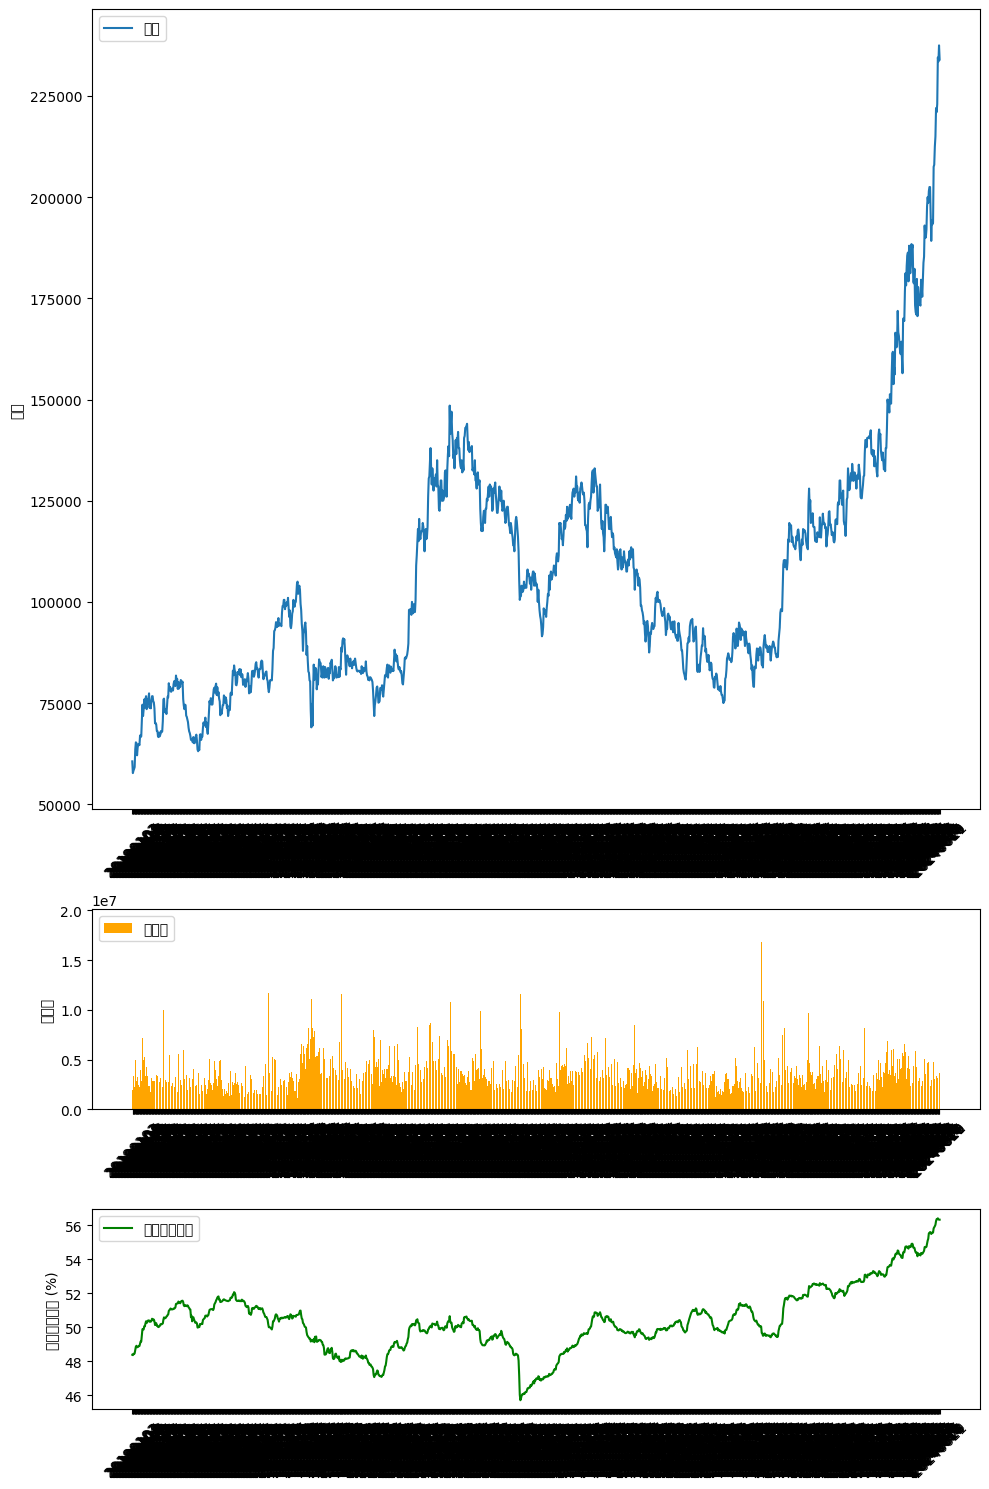

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import urllib.request

# Step 1: Define the get_price function
def get_price(company_code, start_day, end_day):
    url = f"https://m.stock.naver.com/front-api/external/chart/domestic/info?symbol={company_code}&requestType=1&startTime={start_day}&endTime={end_day}&timeframe=day"
    response = urllib.request.urlopen(url)
    html = response.read()
    res = html.decode('utf-8').strip()
    res_list = eval(res)

    df = pd.DataFrame(res_list[1:], columns=res_list[0])
    df.index = pd.to_datetime(df['날짜']).dt.strftime("%Y%m%d") # Set row indices.
    return df

# Step 2: Retrieve Data
company_code = '000660'  # SK hynix
start_day = '20190101'
end_day = datetime.now().strftime('%Y%m%d')

df = get_price(company_code, start_day, end_day)

# Check the data types of the columns
print(df.dtypes)

# Ensure columns are strings
df['종가'] = df['종가'].astype(str)
df['거래량'] = df['거래량'].astype(str)
df['외국인소진율'] = df['외국인소진율'].astype(str)

# Converting columns to appropriate data types
df['종가'] = pd.to_numeric(df['종가'].str.replace(',', ''))
df['거래량'] = pd.to_numeric(df['거래량'].str.replace(',', ''))
df['외국인소진율'] = pd.to_numeric(df['외국인소진율'].str.replace('%', ''))

# Step 3: Plotting
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15), gridspec_kw={'height_ratios': [4, 1, 1]})

# Closing price plot (4 parts)
axes[0].plot(df.index, df['종가'], label='종가')
axes[0].set_ylabel('종가')
axes[0].legend(loc='upper left')

# Volume plot (1 part)
axes[1].bar(df.index, df['거래량'], label='거래량', color='orange')
axes[1].set_ylabel('거래량')
axes[1].legend(loc='upper left')

# Foreign ownership rate plot (1 part)
axes[2].plot(df.index, df['외국인소진율'], label='외국인소진율', color='green')
axes[2].set_ylabel('외국인소진율 (%)')
axes[2].legend(loc='upper left')

# Setting the x-axis labels to be more readable
for ax in axes:
    plt.sca(ax)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
